# 🔬 PathVQA-Lite | Notebook 1 of 3
## Data Preprocessing, EDA & Dataset Engineering (Colab Optimized)

---

### 🎯 Notebook Objective
This notebook acts as the **data foundation** of the pipeline. Garbage in, garbage out carries life-or-death consequences in medical AI.

**What we build:**
1. Google Drive mounting & persistent folder structuring
2. Dataset loading from HuggingFace + local fallback
3. Pathology image EDA — color distributions, resolution analysis
4. QA pair analysis — question taxonomy, vocabulary stats
5. Stain normalization (Macenko method)
6. Class imbalance mitigation
7. Medical-grade augmentation pipeline (domain-aware)
8. Tokenizer setup (CLIP + BiomedBERT)
9. Production-ready `PathVQADataset` class + `collate_fn`
10. Exporting all artifacts to persistent Drive storage

In [1]:
# ── Cell 1: Colab Setup & Package Installs ──────────────────────────────────
import sys

# 1. Mount Google Drive (Persistent Storage)
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    print("Not running in Google Colab. Using local file system.")
    IN_COLAB = False

# 2. Install required packages silently
print("\nInstalling required packages (this takes a minute)...")
!pip install -q transformers datasets timm
!pip install -q staintools spams wordcloud

print("✅ Environment ready.")

Mounting Google Drive...
Mounted at /content/drive

Installing required packages (this takes a minute)...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for spams (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for spams
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (spams)
✅ Environment ready.


In [2]:
# ── Cell 2: Core Imports & Professional Folder Config ───────────────────────
import os
import json
import random
import warnings
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import cv2

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import CLIPTokenizer, AutoTokenizer,CLIPModel
from datasets import load_dataset, DatasetDict

warnings.filterwarnings("ignore")

# ── Reproducibility (critical for medical AI) ────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Global config object ──────
@dataclass
class PathVQAConfig:
    # Placeholder for project_root (set in post_init)
    project_root:      Path = field(default_factory=Path)

    # Dataset & Hyperparameters
    hf_dataset_name:   str  = "flaviagiammarino/path-vqa"
    image_size:        int  = 224
    image_mean:        Tuple = (0.48145466, 0.4578275, 0.40821073)  # CLIP stats
    image_std:         Tuple = (0.26862954, 0.26130258, 0.27577711)
    tokenizer_name:    str  = "openai/clip-vit-base-patch32"
    bio_tokenizer:     str  = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
    max_text_length:   int  = 77
    batch_size:        int  = 32

    def __post_init__(self):
        # 1. Setup Persistent Project Root safely
        if 'IN_COLAB' in globals() and IN_COLAB:
            self.project_root = Path("/content/drive/MyDrive/PathVQA_Project")
        else:
            self.project_root = Path("./PathVQA_Project")

        # 2. Map Professional Folder Structure
        self.data_dir       = self.project_root / "datasets"
        self.output_dir     = self.project_root / "outputs"
        self.checkpoint_dir = self.project_root / "checkpoints"
        self.artifact_dir   = self.project_root / "artifacts"
        self.results_dir    = self.project_root / "results"
        self.log_dir        = self.project_root / "logs"
        self.cache_dir      = self.project_root / "cache"

        # 3. Create folders automatically
        directories = [
            self.data_dir, self.output_dir, self.checkpoint_dir,
            self.artifact_dir, self.results_dir, self.log_dir, self.cache_dir
        ]
        for d in directories:
            d.mkdir(parents=True, exist_ok=True)

CFG = PathVQAConfig()

# Check Device & Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"📁 Project Root: {CFG.project_root}")
print(f"✅ All persistent folders verified.")

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
📁 Project Root: /content/drive/MyDrive/PathVQA_Project
✅ All persistent folders verified.


## Section 1: Dataset Loading

**Why PathVQA?**
It contains ~32,799 Q&A pairs on H&E stained pathology images. About 50% are Yes/No questions, and 50% are Open-ended. This forces us to design a **hybrid answering head**.

In [3]:
# ── Cell 3: Load PathVQA from HuggingFace ────────────────────────────────────
# We use our persistent cache_dir so we don't redownload every session

def load_pathvqa(cfg: PathVQAConfig) -> DatasetDict:
    print(f"📥 Loading '{cfg.hf_dataset_name}' from HuggingFace...")
    try:
        dataset = load_dataset(
            cfg.hf_dataset_name,
            cache_dir=str(cfg.cache_dir),
            trust_remote_code=True,
        )
        print(f"✅ Loaded successfully.")
        for split, ds in dataset.items():
            print(f"   {split:10s}: {len(ds):,} samples")
        return dataset
    except Exception as e:
        print(f"⚠️  Load failed: {e}")
        return None

DATASET = load_pathvqa(CFG)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


📥 Loading 'flaviagiammarino/path-vqa' from HuggingFace...


README.md:   0%|          | 0.00/4.29k [00:00<?, ?B/s]

✅ Loaded successfully.
   train     : 19,654 samples
   validation: 6,259 samples
   test      : 6,719 samples


In [4]:
# ── Cell 4: Convert to pandas for EDA ────────────────────────────────────────

def hf_split_to_df(hf_split, split_name: str, max_samples: int = -1) -> pd.DataFrame:
    n = len(hf_split) if max_samples == -1 else min(max_samples, len(hf_split))
    rows = []
    for i in range(n):
        item = hf_split[i]
        img  = item["image"] if isinstance(item["image"], Image.Image) else Image.fromarray(item["image"])
        ans  = str(item["answer"]).strip().lower()
        rows.append({
            "split":    split_name,
            "question": item["question"],
            "answer":   ans,
            "img_mode": img.mode,
            "q_len":    len(item["question"].split()),
            "a_len":    len(ans.split()),
            "is_binary": ans in ("yes", "no"),
        })
    return pd.DataFrame(rows)

# Use full dataset for stats
dfs = {split: hf_split_to_df(DATASET[split], split) for split in DATASET.keys()}
df_all = pd.concat(dfs.values(), ignore_index=True)
df_train = dfs.get("train", df_all)

print(df_all.groupby("split")[["question","is_binary"]].agg(
    total=("question","count"),
    binary_pct=("is_binary","mean")
).round(3).to_string())

            total  binary_pct
split                        
test         6719       0.500
train       19654       0.496
validation   6259       0.499


## Section 2: EDA & Medical Image Characteristics

Histopathology images have strong pink/purple biases (H&E stain). If we rely solely on ImageNet normalizations, the model fails to learn true pathology features.

📊 PathVQA RGB Channel Statistics:
   Mean: R=0.6323  G=0.5105  B=0.6001
   Std:  R=0.1948  G=0.2036  B=0.1756


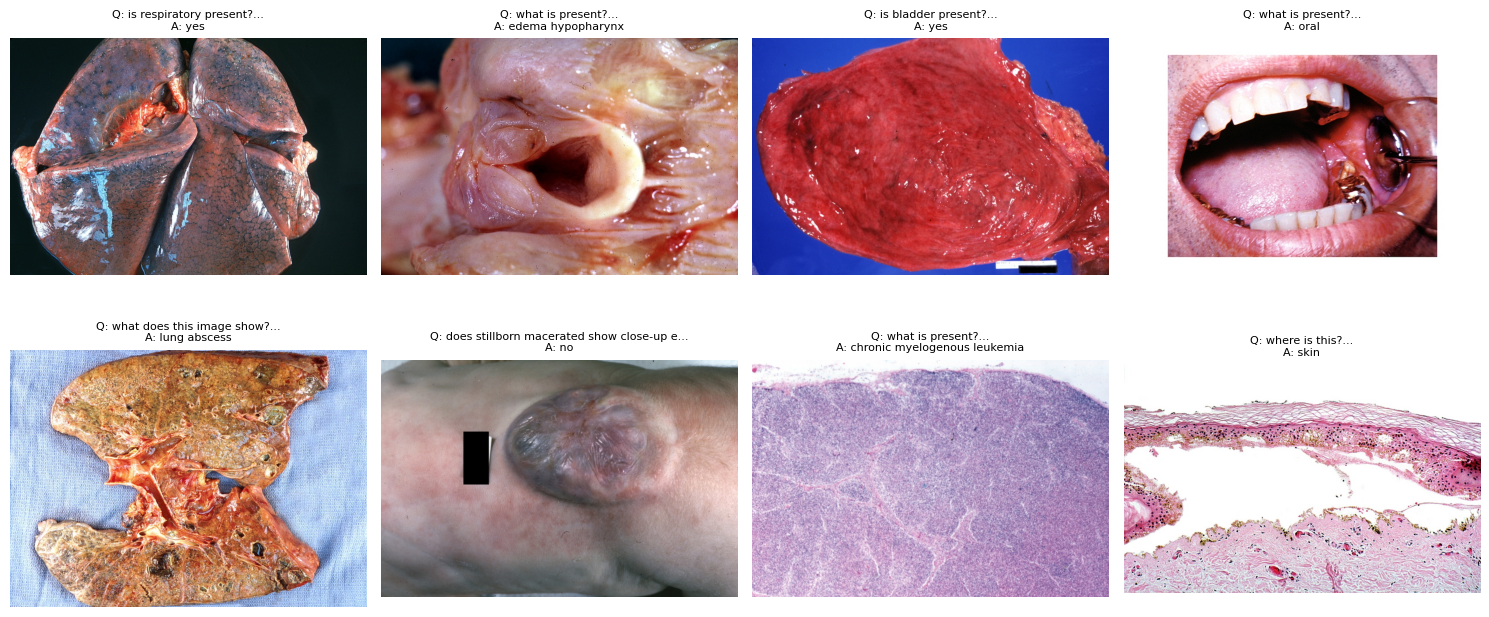

In [5]:
# ── Cell 5: RGB Channel Stats ────────────────────────────────────────────────
# Notice we save the plot to CFG.output_dir (Persistent Drive)

def compute_channel_stats(hf_split, n_samples: int = 300) -> Dict[str, List[float]]:
    means, stds = [], []
    indices = random.sample(range(len(hf_split)), min(n_samples, len(hf_split)))
    for i in indices:
        img = hf_split[i]["image"]
        if not isinstance(img, Image.Image): img = Image.fromarray(img)
        arr = np.array(img.convert("RGB").resize((224, 224)), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        stds.append(arr.std(axis=(0, 1)))
    return {"mean": np.array(means).mean(axis=0).tolist(), "std": np.array(stds).mean(axis=0).tolist()}

train_split = DATASET["train"]
STATS = compute_channel_stats(train_split)

print("📊 PathVQA RGB Channel Statistics:")
print(f"   Mean: R={STATS['mean'][0]:.4f}  G={STATS['mean'][1]:.4f}  B={STATS['mean'][2]:.4f}")
print(f"   Std:  R={STATS['std'][0]:.4f}  G={STATS['std'][1]:.4f}  B={STATS['std'][2]:.4f}")

# Sample Grid
indices = random.sample(range(len(train_split)), 8)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, idx in zip(axes.ravel(), indices):
    item = train_split[idx]
    img = item["image"].convert("RGB") if isinstance(item["image"], Image.Image) else Image.fromarray(item["image"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Q: {item['question'][:40]}...\nA: {item['answer']}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(CFG.output_dir / "eda_sample_grid.png", dpi=150) # Saved to Drive
plt.show()


## Section 3: Question/Answer & Class Imbalance Analysis
This determines our **vocabulary size** and **loss weights**.

In [7]:
# ── Cell 6: Build Vocab & Class Weights ──────────────────────────────────────
import torch.nn.functional as F
from transformers import CLIPTokenizer, CLIPModel

def build_answer_vocab(df: pd.DataFrame, top_k: int = 4943) -> Dict:
    vocab = {"yes": 0, "no": 1}
    offset = 2
    open_cnts = Counter(df[~df["is_binary"]]["answer"].tolist())
    for ans, _ in open_cnts.most_common(top_k):
        if ans not in vocab:
            vocab[ans] = offset
            offset += 1
    vocab["<UNK>"] = offset
    return vocab

VOCAB = build_answer_vocab(df_train, top_k=4943)
INV_VOCAB = {v: k for k, v in VOCAB.items()}

print(f"📚 Total Vocab Size: {len(VOCAB)}")

def precompute_answer_embeddings(vocab: dict, clip_model_name: str, cache_dir: str) -> torch.Tensor:
    """Encode each answer string → 512-dim CLIP text embedding."""
    tok   = CLIPTokenizer.from_pretrained(clip_model_name, cache_dir=cache_dir)
    model = CLIPModel.from_pretrained(clip_model_name, cache_dir=cache_dir)
    model.eval()
    inv   = {v: k for k, v in vocab.items()}
    embeddings = torch.zeros(len(vocab), 512)

    with torch.no_grad():
        for idx in range(len(vocab)):
            ans = inv.get(idx, "<UNK>")
            enc = tok(ans, return_tensors="pt",
                      max_length=20, padding="max_length", truncation=True)

            # Get text features from HuggingFace
            emb = model.get_text_features(**enc)

            # --- FIX: Safely extract the tensor if HF returned an object ---
            if not isinstance(emb, torch.Tensor):
                if hasattr(emb, "text_embeds"):
                    emb = emb.text_embeds
                elif hasattr(emb, "pooler_output"):
                    emb = emb.pooler_output
                else:
                    emb = emb[0] # Fallback to tuple unpacking
            # ---------------------------------------------------------------

            embeddings[idx] = F.normalize(emb, dim=-1)

    return embeddings

ANSWER_EMBEDDINGS = precompute_answer_embeddings(VOCAB, CFG.tokenizer_name, str(CFG.cache_dir))
torch.save(ANSWER_EMBEDDINGS, CFG.artifact_dir / "answer_embeddings.pt")
print(f"Saved answer embeddings: {ANSWER_EMBEDDINGS.shape}")

# Compute class weights for imbalanced data
def compute_class_weights(df: pd.DataFrame, vocab: Dict[str, int]) -> torch.Tensor:
    counts = np.zeros(len(vocab), dtype=np.float32)
    for ans in df["answer"]:
        counts[vocab.get(ans, vocab.get("<UNK>"))] += 1
    counts = np.maximum(counts, 1)
    weights = len(df) / (len(vocab) * counts)
    return torch.tensor(np.clip(weights, 0.1, 50.0), dtype=torch.float32)

CLASS_WEIGHTS = compute_class_weights(df_train, VOCAB)
print(f"⚖️ Class weights computed. Min: {CLASS_WEIGHTS.min():.2f}, Max: {CLASS_WEIGHTS.max():.2f}")

📚 Total Vocab Size: 3226


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Saved answer embeddings: torch.Size([3226, 512])
⚖️ Class weights computed. Min: 0.10, Max: 6.09


## Section 4: Stain Normalization & Augmentation
**Crucial Medical Concept:** We cannot use severe color jitter. It might make Eosin (pink) look like Hematoxylin (blue), invalidating the diagnosis. We use Macenko Normalization and safe spatial transforms.

In [8]:
# ── Cell 7: Macenko Normalization & Transforms ───────────────────────────────

class MacenkoNormalizer:
    """Mathematical extraction of H&E stain vectors via SVD."""
    def __init__(self, alpha: int = 1, beta: float = 0.15):
        self.target = None
        self._warning_printed = False
        try:
            import staintools
            self.normalizer = staintools.MacenkoNormalizer()
            self.available = True
        except ImportError:
            print("⚠️ WARNING: 'staintools' or 'spams' failed to install/import. Macenko Normalization is safely disabled.")
            self.available = False

    def fit(self, ref_image: Image.Image):
        if not self.available: return self
        import staintools
        self.target = staintools.LuminosityStandardizer.standardize(np.array(ref_image))
        self.normalizer.fit(self.target)
        return self

    def transform(self, img: Image.Image) -> Image.Image:
        if not self.available or self.target is None: return img
        try:
            import staintools
            to_transform = staintools.LuminosityStandardizer.standardize(np.array(img))
            transformed = self.normalizer.transform(to_transform)
            return Image.fromarray(transformed)
        except Exception as e:
            if not self._warning_printed:
                print(f"⚠️ WARNING: Stain normalization failed on sample ({e}). Safely falling back to original image.")
                self._warning_printed = True
            return img

# Train / Eval Transforms
def build_transforms(cfg: PathVQAConfig, split: str = "train") -> T.Compose:
    mean, std = cfg.image_mean, cfg.image_std
    resize = T.Resize((cfg.image_size, cfg.image_size))

    if split == "train":
        return T.Compose([
            resize,
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(degrees=180), # Safe for cells
            T.ColorJitter(brightness=0.05, contrast=0.05), # Mild only!
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])
    return T.Compose([resize, T.ToTensor(), T.Normalize(mean=mean, std=std)])

TRAIN_TRANSFORM = build_transforms(CFG, "train")
EVAL_TRANSFORM  = build_transforms(CFG, "val")

## Section 5: Tokenizer Setup

In [9]:
# ── Cell 8: Tokenizers ───────────────────────────────────────────────────────
# We use cache_dir so HuggingFace models download to Drive persistently

print("📝 Loading Tokenizers...")
CLIP_TOKENIZER = CLIPTokenizer.from_pretrained(CFG.tokenizer_name, cache_dir=str(CFG.cache_dir))
try:
    BIO_TOKENIZER = AutoTokenizer.from_pretrained(CFG.bio_tokenizer, cache_dir=str(CFG.cache_dir))
except:
    print("Fallback to CLIP tokenizer")
    BIO_TOKENIZER = CLIP_TOKENIZER

print(f"CLIP Vocab size: {CLIP_TOKENIZER.vocab_size:,}")

📝 Loading Tokenizers...
CLIP Vocab size: 49,408


## Section 6: Production Dataset & Dataloader
This implements the RAM-friendly `__getitem__` pipeline and the custom `collate_fn` which is necessary to handle strings inside batches.

In [10]:
class PathVQADataset(Dataset):
    def __init__(self, hf_split, vocab: Dict[str, int], tokenizer, transform, max_len: int = 77):
        self.hf_split = hf_split
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len
        self._unk_idx = vocab.get("<UNK>", len(vocab)-1)

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx: int):
        try:
            item = self.hf_split[idx]
            img = item["image"].convert("RGB") if isinstance(item["image"], Image.Image) else Image.fromarray(item["image"]).convert("RGB")
            ans = str(item["answer"]).strip().lower()

            img_tensor = self.transform(img)

            enc = self.tokenizer(
                str(item["question"]), max_length=self.max_len,
                padding="max_length", truncation=True, return_tensors="pt"
            )

            is_bin = int(ans in ("yes", "no"))
            ans_idx = self.vocab.get(ans, self._unk_idx)

            return {
                "image": img_tensor,
                "input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "answer_class": torch.tensor(ans_idx, dtype=torch.long),
                "is_binary": torch.tensor(is_bin, dtype=torch.bool),
                "question_text": str(item["question"]),
                "answer_text": ans
            }
        except Exception as e:
            # Fallback to empty tensor on corruption
            return {
                "image": torch.zeros(3, CFG.image_size, CFG.image_size),
                "input_ids": torch.zeros(self.max_len, dtype=torch.long),
                "attention_mask": torch.zeros(self.max_len, dtype=torch.long),
                "answer_class": torch.tensor(0, dtype=torch.long),
                "is_binary": torch.tensor(False, dtype=torch.bool),
                "question_text": "", "answer_text": ""
            }

def pathvqa_collate_fn(batch):
    out = {}
    for k in ["image", "input_ids", "attention_mask", "answer_class", "is_binary"]:
        out[k] = torch.stack([b[k] for b in batch])
    for k in ["question_text", "answer_text"]:
        out[k] = [b[k] for b in batch]
    return out

# Dataloader instantiation uses pin_memory based on CUDA availability
DATALOADERS = {}
splits_to_build = [
    ("train", "train", TRAIN_TRANSFORM),
    ("val", "validation", EVAL_TRANSFORM),
    ("test", "test", EVAL_TRANSFORM)       # Added test split here
]

for split, hf_key, transform in splits_to_build:
    if hf_key in DATASET:  # Safety check in case synthetic dataset is used
        ds = PathVQADataset(DATASET[hf_key], VOCAB, CLIP_TOKENIZER, transform, CFG.max_text_length)
        DATALOADERS[split] = DataLoader(
            ds, batch_size=CFG.batch_size, shuffle=(split=="train"),
            num_workers=2, pin_memory=torch.cuda.is_available(),
            collate_fn=pathvqa_collate_fn, drop_last=(split=="train")
        )
        print(f"✅ DataLoader '{split}' prepared with {len(ds)} samples.")

print("All DataLoaders ready.")

✅ DataLoader 'train' prepared with 19654 samples.
✅ DataLoader 'val' prepared with 6259 samples.
✅ DataLoader 'test' prepared with 6719 samples.
All DataLoaders ready.


## Section 7: Exporting Artifacts to Drive (Crucial Step)

If the Colab runtime disconnects right now, we would normally lose everything.
Because we are saving everything to `CFG.artifact_dir`, we can skip Notebook 1 entirely tomorrow and go straight to Notebook 2!

In [11]:
# ── Cell 10: Export Artifacts to Persistent Storage ───────────────────────────

# 1. Config -> JSON
cfg_dict = {k: str(v) if isinstance(v, Path) else v for k, v in CFG.__dict__.items()}
with open(CFG.artifact_dir / "config.json", "w") as f:
    json.dump(cfg_dict, f, indent=2)

# 2. Vocab -> JSON
with open(CFG.artifact_dir / "answer_vocab.json", "w") as f:
    json.dump({"vocab": VOCAB, "inv_vocab": {str(k): v for k, v in INV_VOCAB.items()}}, f)

# 3. Class Weights -> PT
torch.save(CLASS_WEIGHTS, CFG.artifact_dir / "class_weights.pt")

# 4. Dataset Stats -> JSON
stats_dict = {
    "splits": {k: len(v) for k, v in DATASET.items()},
    "vocab_size": len(VOCAB),
    "channel_mean": STATS["mean"],
    "channel_std": STATS["std"]
}
with open(CFG.artifact_dir / "dataset_stats.json", "w") as f:
    json.dump(stats_dict, f, indent=2)

print(f"🎉 SUCCESS! All artifacts saved securely to Google Drive:")
print(f"Directory: {CFG.artifact_dir}")
for p in sorted(CFG.artifact_dir.iterdir()):
    print(f"   📄 {p.name:<25} ({p.stat().st_size/1024:.1f} KB)")

print("\n🚀 You are now ready to open Notebook 2 (Training)!")

🎉 SUCCESS! All artifacts saved securely to Google Drive:
Directory: /content/drive/MyDrive/PathVQA_Project/artifacts
   📄 answer_embeddings.pt      (6453.6 KB)
   📄 answer_vocab.json         (277.5 KB)
   📄 class_weights.pt          (14.1 KB)
   📄 config.json               (0.9 KB)
   📄 dataset_stats.json        (0.3 KB)
   📄 train_config.json         (1.0 KB)

🚀 You are now ready to open Notebook 2 (Training)!
